# No debt simulation
The agents exchange a fixed amount of money and debt is not allowed.


In [1]:
import functions as func
import matplotlib.pyplot as plt
import numpy as np



In [2]:
N = 3500
M = 10e4
steps = 8e6


agents = func.simulate_no_debt(N=N, M=M, steps=steps, transaction_type='constant')

print(f"Shape: {agents.shape}")
print(f"Total money: {agents.sum():.2f}")
print(f"Minimum: {agents.min():.2f}")
print(f"Maximum: {agents.max():.2f}")
print("First 10 agents:", agents[:10])

Shape: (3500,)
Total money: 100000.00
Minimum: 0.57
Maximum: 199.57
First 10 agents: [ 14.57142857  12.57142857 103.57142857  19.57142857  13.57142857
  83.57142857  25.57142857   7.57142857  72.57142857  15.57142857]


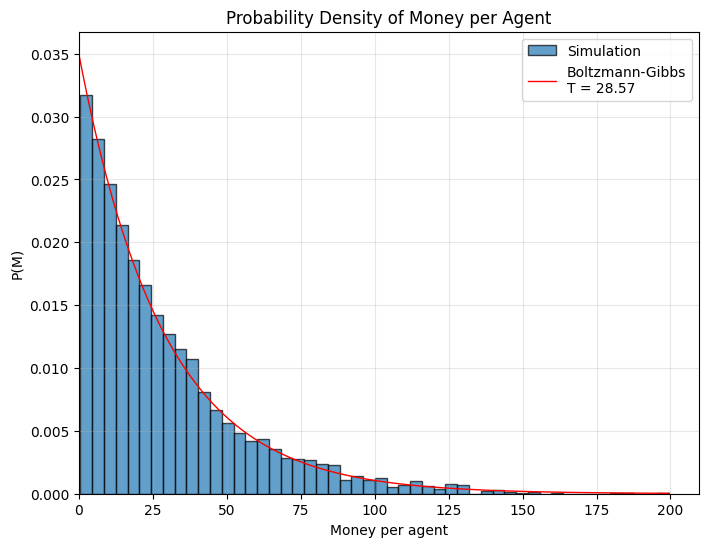

In [37]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

T = M / N

fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(
    agents,
    bins=50,
    density=True,
    alpha=0.7,
    edgecolor="black",
    label="Simulation"
)

x_fit = np.linspace(0, agents.max(), 300)
y_fit = (1 / T) * np.exp(-x_fit / T)

plt.plot(
    x_fit,
    y_fit,
    "r-",
    linewidth=1,
    label=f"Boltzmann-Gibbs\nT = {T:.2f}"
)

plt.xlabel("Money per agent")
plt.ylabel("P(M)")
plt.title("Probability Density of Money per Agent")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, agents.max() + 10)
plt.show()

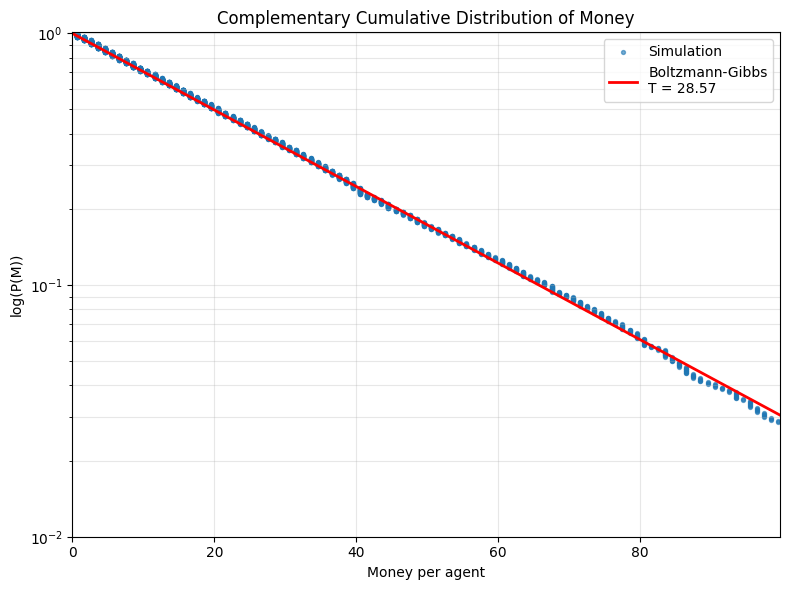

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))

sorted_agents = np.sort(agents)
probability = 1 - np.arange(1, N + 1) / N  # complementary cumulative probability

ax.scatter(
    sorted_agents,
    probability,
    s=8,
    alpha=0.6,
    label="Simulation"
)

ax.plot(
    x_fit,
    np.exp(-x_fit / T),
    "r-",
    linewidth=2,
    label=f"Boltzmann-Gibbs\nT = {T:.2f}"
)

ax.set_yscale("log")
ax.set_xlabel("Money per agent")
ax.set_ylabel("log(P(M))")
ax.set_title("Complementary Cumulative Distribution of Money")
ax.legend()
ax.grid(which="both", alpha=0.3)
#ax.set_xlim(0, agents.max())
ax.set_xlim(0, agents.max()/2)
ax.set_ylim(1e-2, 1.01)  # Set y-axis limits for better visibility

plt.tight_layout()
plt.show()